In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from preprocessing import functions
import cv2 as cv

In [2]:
dir = r"D:\data"

# Methodology
1. Import images and convert to LAB
2. ~~Augment image data by the following technique~~
    - ~~Color enhancement in HSV chanel~~
        - ~~H chennel shifted between (-10,10)~~
        - ~~S channel multiplied by a parameter between 0.9 - 1.5~~
    - ~~Brigtness enhancement with factor between 0.9 - 1.5 and beta between 20-50~~
3. Denormalize value
    - **L chanel** range = (0,100) : `L_norm = L / 100`
    - **a&b chanel** range = (-128,127) : `ch_norm = (ch + 128) / 255`
4. Extract color masks from originals

# Image import and augmentation

In [3]:

images = []

files = os.listdir(dir)

for fname in files:
    file = f"{dir}/{fname}"
    try: 
        img = cv.cvtColor(cv.imread(file), code=cv.COLOR_BGR2LAB)
        img = functions.autoCrop(img)
        img = functions.normalizeLAB(img)
        images.append(img)
    except: pass
        
images = np.stack(images)
np.random.shuffle(images)
masks = functions.extractColorMask(images, n_cell=4)   

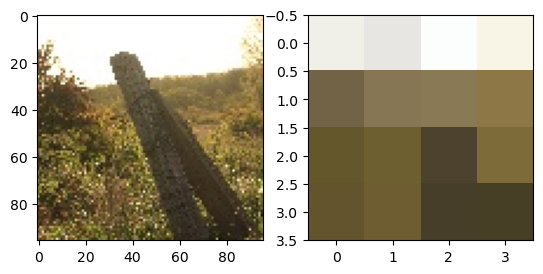

In [4]:
test_img = functions.denormalizeLAB(images[0]).astype(np.uint8)
test_img = cv.cvtColor(test_img, code=cv.COLOR_LAB2RGB)
test_mask = functions.denormalizeLAB(masks[0]).astype(np.uint8)
test_mask = cv.cvtColor(test_mask, code=cv.COLOR_LAB2RGB)

plt.subplot(1,2,1).imshow(test_img)
plt.subplot(1,2,2).imshow(test_mask)

In [ ]:
np.save(f"./dataset/labs.npy", images)
np.save(f"./dataset/masks.npy", masks)